# Customer Intelligence System
## Unsupervised + Supervised Learning on Country Data


An end-to-end intelligence system to classify and segment countries based on socio-economic indicators, achieving optimized predictive performance and actionable segmentation insights.


## 1. Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, accuracy_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               StackingClassifier, VotingClassifier)
from sklearn.neighbors import NearestNeighbors
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')
sns.set(style='whitegrid')

## 2. Load & Clean Data

Missing values are imputed with the column median — robust to the heavy right-skew present in economic indicators like `gdpp` and `income`.

In [ ]:
df = pd.read_csv('Country-data.csv')
df.columns = [c.strip().lower() for c in df.columns]
df.drop_duplicates(inplace=True)
numeric_cols = [c for c in df.columns if c != 'country']
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
df.describe().round(2)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,38.27,41.11,6.82,46.89,17144.69,7.78,70.56,2.95,12964.16
std,40.33,27.41,2.75,24.21,19278.07,10.57,8.89,1.51,18328.70
min,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,8.25,23.80,4.92,30.20,3355.00,1.81,65.30,1.80,1330.00
50%,19.30,35.00,6.32,43.30,9960.00,5.39,73.10,2.41,4660.00
75%,62.10,51.35,8.60,58.75,22800.00,10.75,76.80,3.88,14050.00
max,208.00,200.00,17.90,174.00,125000.00,104.00,82.80,7.49,105000.00


## 3. Exploratory Data Analysis

EDA guides downstream decisions — which features to scale, where correlations exist, and where outliers lie.

### 3.1 Feature Distributions

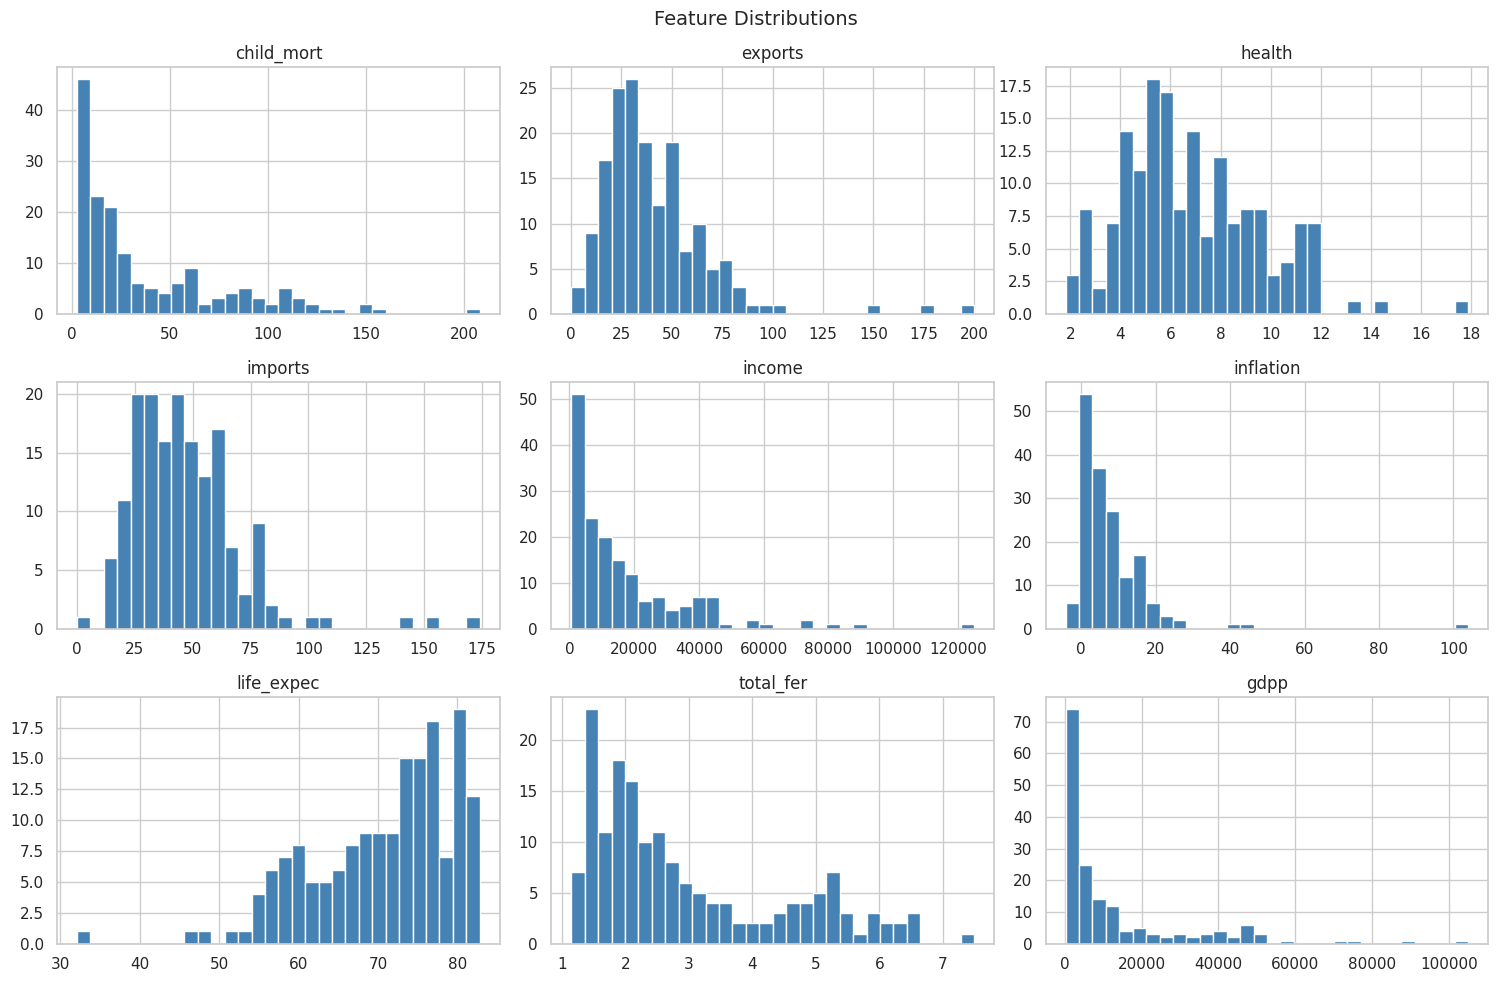

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
plt.suptitle('Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

`gdpp` and `income` are heavily right-skewed, confirming the need for `StandardScaler` before any distance-based algorithm.

### 3.2 Boxplots

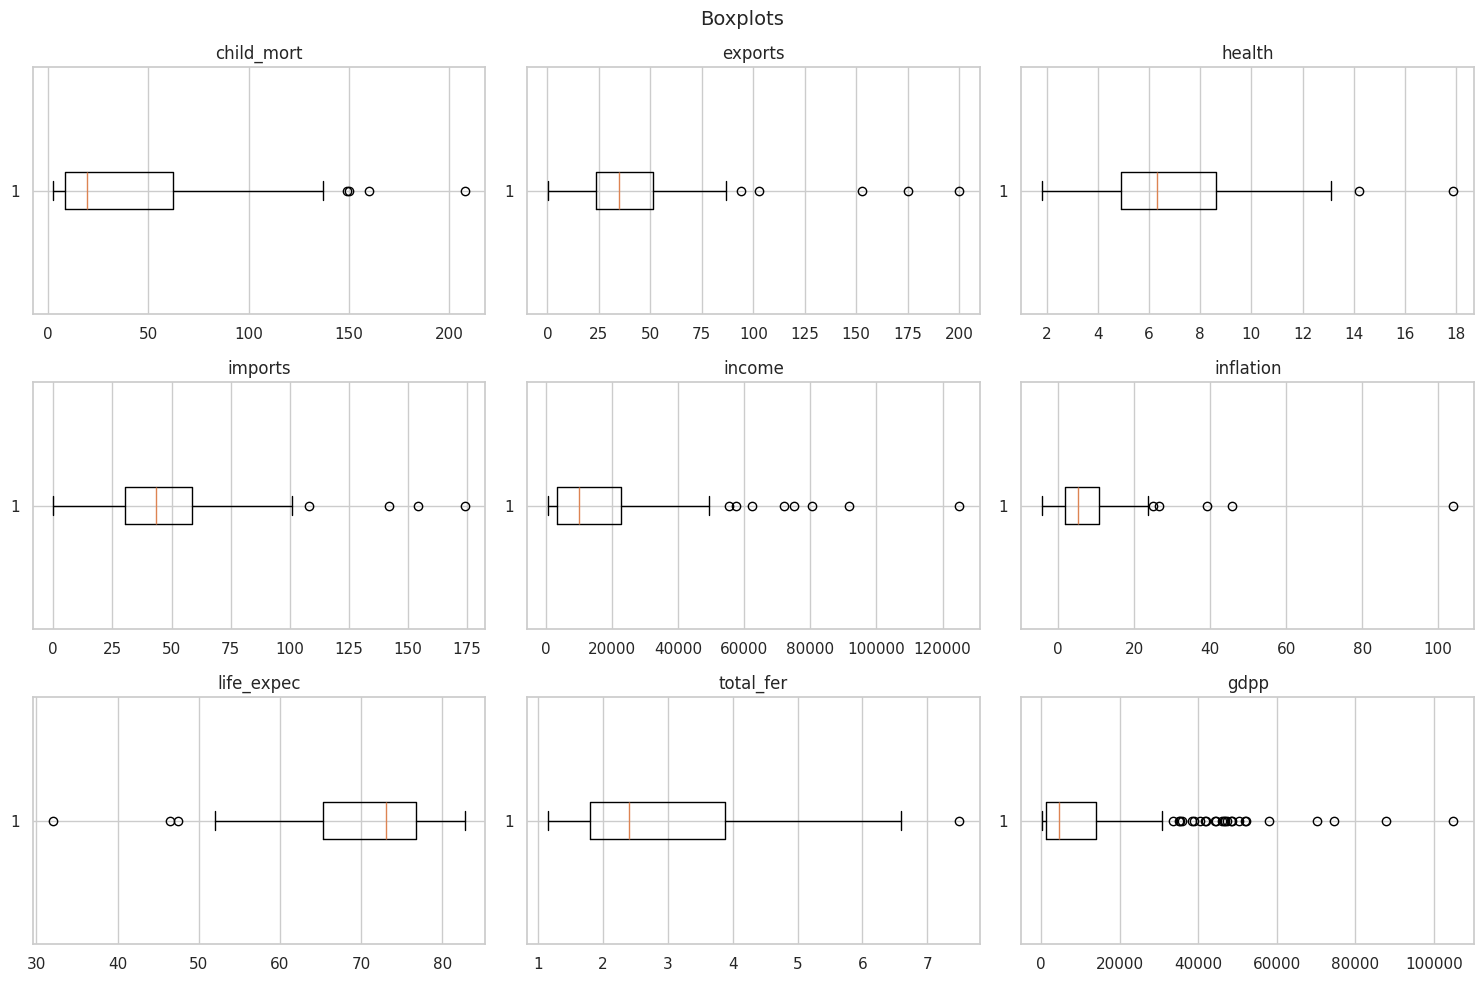

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col], vert=False)
    axes[i].set_title(col)
plt.suptitle('Boxplots', fontsize=14)
plt.tight_layout()
plt.show()

### 3.3 Correlation Heatmap

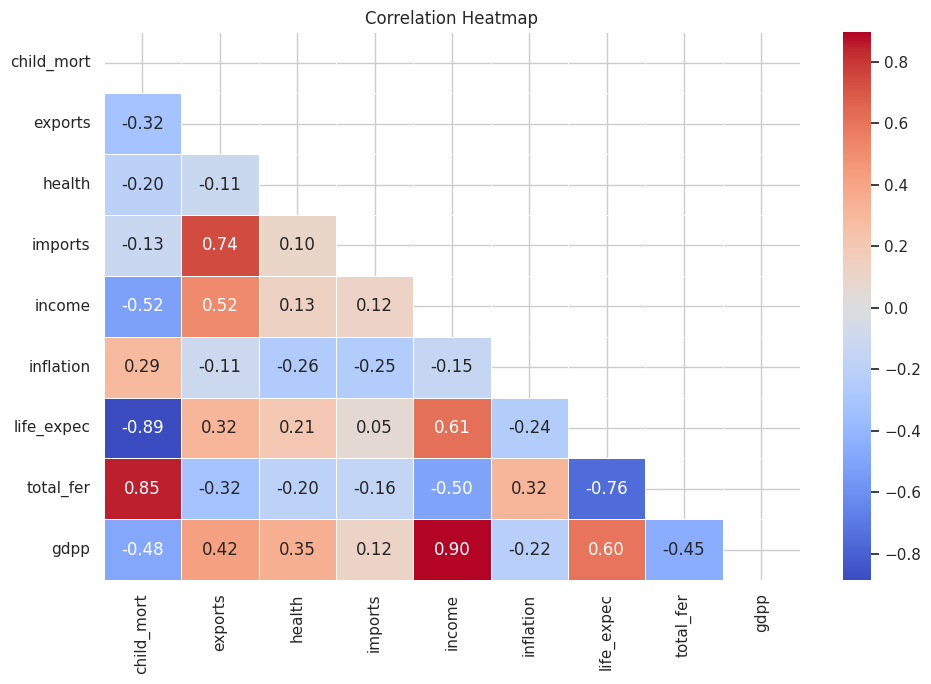

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))
mask = np.triu(np.ones_like(df[numeric_cols].corr(), dtype=bool))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', mask=mask, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.show()

`child_mort` and `total_fer` are strongly negatively correlated with `life_expec` and `gdpp`. Tree-based models handle this multicollinearity naturally; Logistic Regression requires `max_iter=1000` to converge.

### 3.4 GDP per Capita vs Child Mortality

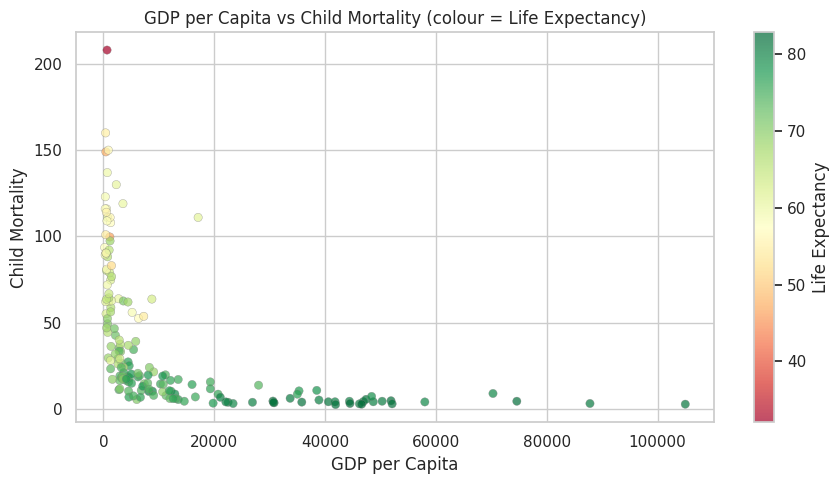

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(df['gdpp'], df['child_mort'], c=df['life_expec'],
                cmap='RdYlGn', alpha=0.7, edgecolors='gray', linewidths=0.3)
plt.colorbar(sc, ax=ax, label='Life Expectancy')
ax.set_xlabel('GDP per Capita')
ax.set_ylabel('Child Mortality')
ax.set_title('GDP per Capita vs Child Mortality (colour = Life Expectancy)')
plt.tight_layout()
plt.show()

Clear non-linear inverse relationship between `gdpp` and `child_mort` — justifies using ensemble tree models over linear classifiers.

## 4. Feature Engineering — Development Tier Label

The dataset has no target column. A composite development score is built from five percentile-ranked indicators:

- **Positive contributors:** `gdpp`, `life_expec`, `income`
- **Negative contributors:** `child_mort`, `total_fer`

Percentile ranking removes unit and scale differences before averaging. Countries are split into 3 tiers at the 33rd and 67th percentiles, giving balanced class sizes and preventing class imbalance from biasing training.

In [ ]:
df['dev_score'] = (
    df['gdpp'].rank(pct=True) +
    df['life_expec'].rank(pct=True) +
    df['income'].rank(pct=True) -
    df['child_mort'].rank(pct=True) -
    df['total_fer'].rank(pct=True)
) / 5

q33, q67 = df['dev_score'].quantile(0.33), df['dev_score'].quantile(0.67)
df['dev_tier'] = pd.cut(df['dev_score'],
                         bins=[-np.inf, q33, q67, np.inf],
                         labels=[0, 1, 2]).astype(int)

tier_map = {0: 'Underdeveloped', 1: 'Developing', 2: 'Developed'}
df['dev_tier'].value_counts().sort_index().rename(tier_map)

dev_tier
Underdeveloped    55
Developing        57
Developed         55
Name: count, dtype: int64

## 5. Train / Test Split & Scaling

`stratify=y` preserves class ratio in each split — important for a 3-class problem on only 167 samples.
`StandardScaler` is fit only on training data and applied to test data to prevent data leakage.

In [ ]:
feature_cols = [c for c in numeric_cols if c != 'dev_score']
X = df[feature_cols]
y = df['dev_tier']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=7, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

## 6. Classification

Five classifiers are evaluated. 5-fold stratified cross-validation is used alongside holdout metrics — more reliable than a single test split given the small dataset.

| Model | Reason |
|---|---|
| Logistic Regression | Linear baseline to confirm non-linearity |
| Decision Tree | Interpretable non-linear baseline |
| Random Forest | Bagging reduces variance via random feature subsampling |
| Gradient Boosting | Sequential boosting corrects residuals of prior trees |
| XGBoost | Regularised boosting (L1/L2) — more robust to overfitting than vanilla GB |

In [ ]:
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=7),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=6, random_state=7),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, max_depth=8, random_state=7),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=150, learning_rate=0.08,
                                                        max_depth=4, random_state=7),
    'XGBoost'             : XGBClassifier(n_estimators=150, learning_rate=0.08,
                                          max_depth=4, eval_metric='mlogloss', random_state=7)
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=7)
X_all_sc = scaler.fit_transform(X)
results, trained = {}, {}

for name, model in models.items():
    cv_f1 = cross_val_score(model, X_all_sc, y, cv=skf, scoring='f1_weighted').mean()
    model.fit(X_train_sc, y_train)
    pred = model.predict(X_test_sc)
    results[name] = {
        'Accuracy'  : round(accuracy_score(y_test, pred), 3),
        'F1 (test)' : round(f1_score(y_test, pred, average='weighted'), 3),
        'CV F1'     : round(cv_f1, 3)
    }
    trained[name] = model

pd.DataFrame(results).T

,Accuracy,F1 (test),CV F1
Logistic Regression,0.853,0.856,0.899
Decision Tree,0.912,0.910,0.893
Random Forest,0.912,0.913,0.946
Gradient Boosting,0.912,0.911,0.923
XGBoost,0.971,0.970,0.952


### 6.1 Model Comparison

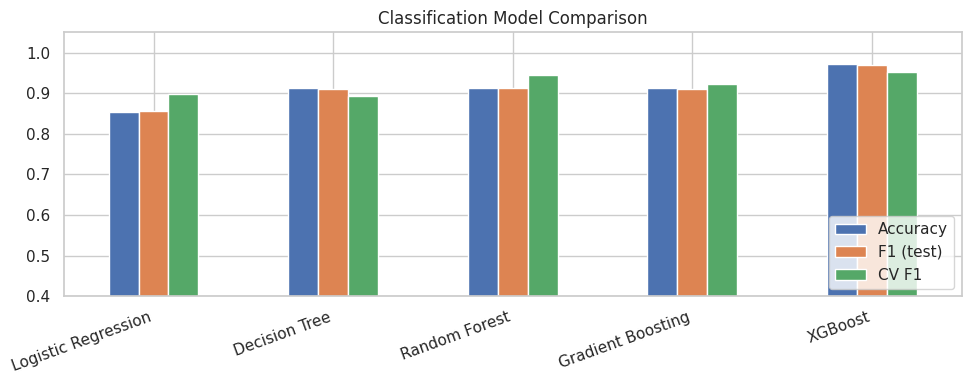

In [ ]:
res_df = pd.DataFrame(results).T
fig, ax = plt.subplots(figsize=(10, 4))
res_df[['Accuracy', 'F1 (test)', 'CV F1']].plot(kind='bar', ax=ax, edgecolor='white')
ax.set_title('Classification Model Comparison')
ax.set_xticklabels(res_df.index, rotation=20, ha='right')
ax.set_ylim(0.4, 1.05)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 6.2 Confusion Matrix — Best Model

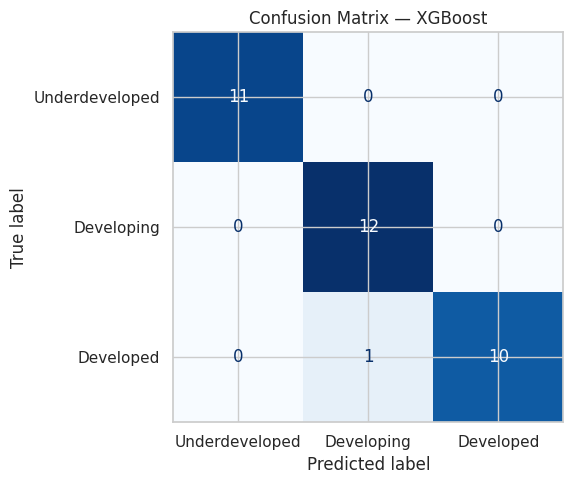

In [ ]:
best = res_df['F1 (test)'].idxmax()
pred = trained[best].predict(X_test_sc)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, pred),
    display_labels=['Underdeveloped', 'Developing', 'Developed']
).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — {best}')
plt.tight_layout()
plt.show()

### 6.3 Feature Importance — Random Forest

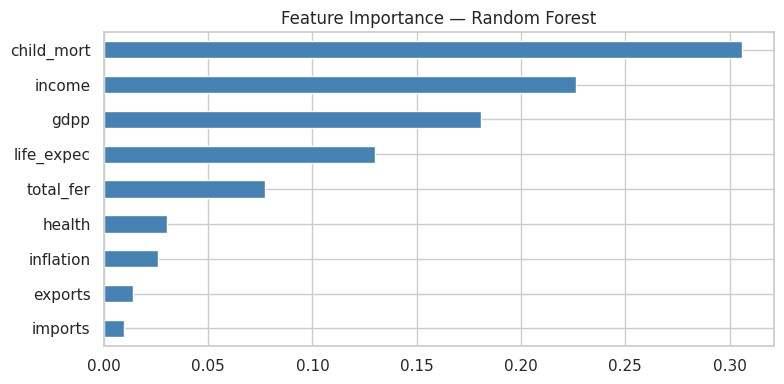

In [ ]:
importances = pd.Series(
    trained['Random Forest'].feature_importances_, index=feature_cols
).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importance — Random Forest')
plt.tight_layout()
plt.show()

## 7. Ensemble Learning

**Soft Voting:** Averages class probabilities from RF, GB, and XGBoost — reduces variance by combining models that make different types of errors.

**Stacking:** RF and XGBoost as base learners; their out-of-fold predictions become input to a Logistic Regression meta-learner. Learns an optimal combination rather than applying a fixed voting rule.

In [ ]:
voting = VotingClassifier(estimators=[
    ('rf',  RandomForestClassifier(n_estimators=200, max_depth=8, random_state=7)),
    ('gb',  GradientBoostingClassifier(n_estimators=150, learning_rate=0.08, max_depth=4, random_state=7)),
    ('xgb', XGBClassifier(n_estimators=150, learning_rate=0.08, max_depth=4,
                           eval_metric='mlogloss', random_state=7))
], voting='soft')
voting.fit(X_train_sc, y_train)

stacking = StackingClassifier(estimators=[
    ('rf',  RandomForestClassifier(n_estimators=200, max_depth=8, random_state=7)),
    ('xgb', XGBClassifier(n_estimators=150, learning_rate=0.08, max_depth=4,
                           eval_metric='mlogloss', random_state=7))
], final_estimator=LogisticRegression(max_iter=1000), cv=5)
stacking.fit(X_train_sc, y_train)

pd.DataFrame({
    'Soft Voting' : {'Accuracy': round(accuracy_score(y_test, voting.predict(X_test_sc)), 3),
                     'F1 (test)': round(f1_score(y_test, voting.predict(X_test_sc), average='weighted'), 3)},
    'Stacking'    : {'Accuracy': round(accuracy_score(y_test, stacking.predict(X_test_sc)), 3),
                     'F1 (test)': round(f1_score(y_test, stacking.predict(X_test_sc), average='weighted'), 3)}
}).T

,Accuracy,F1 (test)
Soft Voting,0.941,0.94
Stacking,0.971,0.97


## 8. Clustering

Applied without the engineered label — purely unsupervised. `StandardScaler` is refit on all features since clustering uses the full dataset.

### 8.1 K-Means — Choosing K

Both criteria are used together to avoid relying on a single heuristic:
- **Elbow method** — where adding another cluster yields diminishing inertia reduction
- **Silhouette score** — measures cluster separation; higher is better

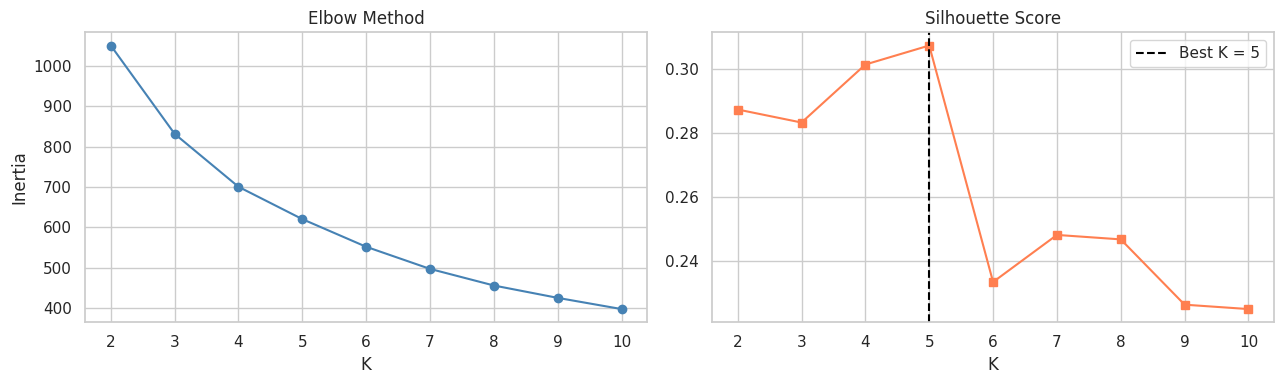

In [ ]:
X_cluster = scaler.fit_transform(df[feature_cols])
inertias, sil_scores = [], []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=7, n_init=15)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(list(k_range), inertias, marker='o', color='steelblue')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia')

best_k = list(k_range)[np.argmax(sil_scores)]
axes[1].plot(list(k_range), sil_scores, marker='s', color='coral')
axes[1].axvline(best_k, color='black', linestyle='--', label=f'Best K = {best_k}')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('K'); axes[1].legend()
plt.tight_layout()
plt.show()

### 8.2 Final K-Means

In [ ]:
kmeans = KMeans(n_clusters=best_k, random_state=7, n_init=15)
df['kmeans_cluster'] = kmeans.fit_predict(X_cluster)
round(silhouette_score(X_cluster, df['kmeans_cluster']), 4)

0.3073

### 8.3 DBSCAN — Tuning eps via k-Distance Plot

Rather than hardcoding `eps`, the k-distance plot is used: distances to the k-th nearest neighbour are sorted descending. The point of maximum curvature is the optimal `eps` — beyond it, points are treated as noise.

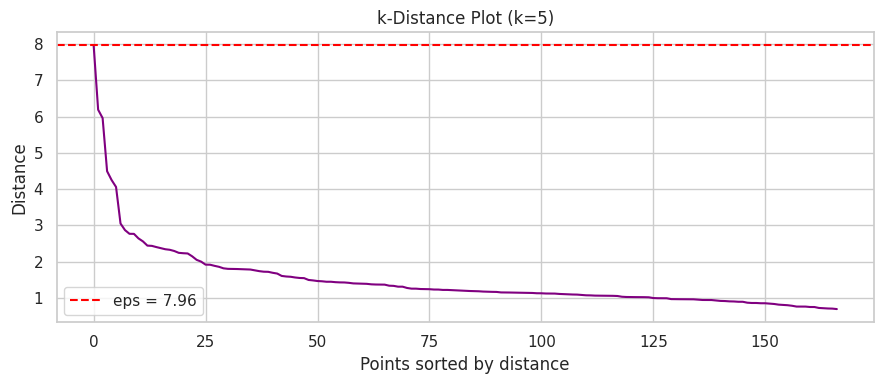

In [ ]:
neigh = NearestNeighbors(n_neighbors=5)
neigh.fit(X_cluster)
distances = np.sort(neigh.kneighbors(X_cluster)[0][:, 4])[::-1]
suggested_eps = round(distances[np.argmax(np.diff(np.diff(distances)))], 2)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(distances, color='purple')
ax.axhline(suggested_eps, color='red', linestyle='--', label=f'eps = {suggested_eps}')
ax.set_title('k-Distance Plot (k=5)')
ax.set_xlabel('Points sorted by distance'); ax.set_ylabel('Distance')
ax.legend()
plt.tight_layout()
plt.show()

### 8.4 DBSCAN

In [ ]:
dbscan = DBSCAN(eps=suggested_eps, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_cluster)
df['dbscan_cluster'].value_counts().sort_index().rename({-1: 'Noise'})

dbscan_cluster
0    167
Name: count, dtype: int64

`-1` denotes noise points — countries with unusual profiles that don't belong to any dense cluster. Unlike K-Means, DBSCAN does not force every point into a cluster.

## 9. PCA Visualization

Reduces 9-dimensional feature space to 2 components for visualisation. Variance explained by each component is shown on axis labels.

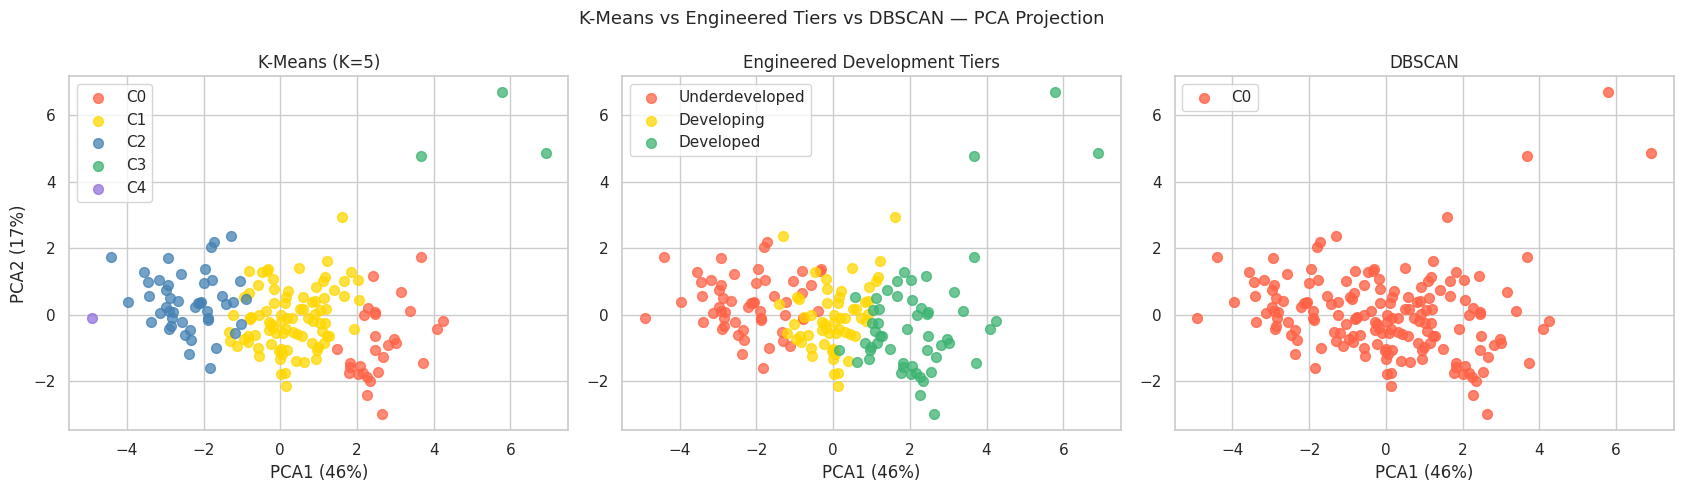

In [ ]:
pca = PCA(n_components=2, random_state=7)
X_pca = pca.fit_transform(X_cluster)
var = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
palette = ['tomato', 'gold', 'steelblue', 'mediumseagreen', 'mediumpurple']

for c in sorted(df['kmeans_cluster'].unique()):
    m = df['kmeans_cluster'] == c
    axes[0].scatter(X_pca[m, 0], X_pca[m, 1], color=palette[c], label=f'C{c}', alpha=0.75, s=50)
axes[0].set_title(f'K-Means (K={best_k})')
axes[0].set_xlabel(f'PCA1 ({var[0]*100:.0f}%)'); axes[0].set_ylabel(f'PCA2 ({var[1]*100:.0f}%)')
axes[0].legend()

tier_colors = {0: 'tomato', 1: 'gold', 2: 'mediumseagreen'}
for t, label in {0: 'Underdeveloped', 1: 'Developing', 2: 'Developed'}.items():
    m = df['dev_tier'] == t
    axes[1].scatter(X_pca[m, 0], X_pca[m, 1], color=tier_colors[t], label=label, alpha=0.75, s=50)
axes[1].set_title('Engineered Development Tiers')
axes[1].set_xlabel(f'PCA1 ({var[0]*100:.0f}%)'); axes[1].legend()

for lbl in sorted(df['dbscan_cluster'].unique()):
    m = df['dbscan_cluster'] == lbl
    name = 'Noise' if lbl == -1 else f'C{lbl}'
    col  = 'lightgray' if lbl == -1 else palette[lbl % len(palette)]
    axes[2].scatter(X_pca[m, 0], X_pca[m, 1], color=col, label=name,
                    alpha=0.5 if lbl == -1 else 0.8, s=50)
axes[2].set_title('DBSCAN')
axes[2].set_xlabel(f'PCA1 ({var[0]*100:.0f}%)'); axes[2].legend()

plt.suptitle('K-Means vs Engineered Tiers vs DBSCAN — PCA Projection', fontsize=13)
plt.tight_layout()
plt.show()

## 10. Cluster Profiling

Mean feature values per K-Means cluster are normalised for the heatmap with raw values annotated, making cross-feature comparison visually meaningful.

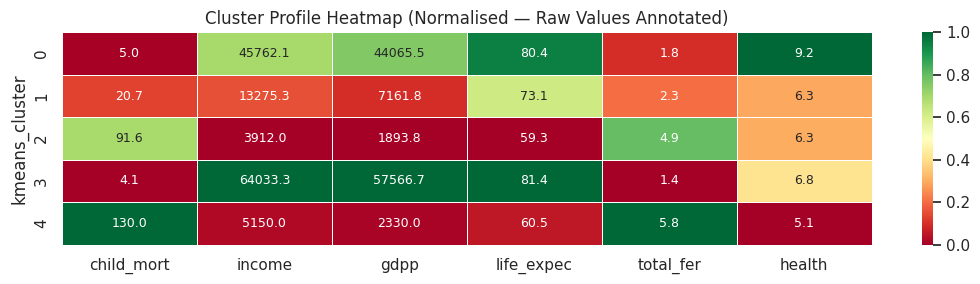

,child_mort,income,gdpp,life_expec,total_fer,health
kmeans_cluster,,,,,,
0,4.98,45762.07,44065.52,80.39,1.81,9.25
1,20.70,13275.29,7161.77,73.09,2.27,6.29
2,91.57,3911.98,1893.83,59.32,4.94,6.32
3,4.13,64033.33,57566.67,81.43,1.38,6.79
4,130.00,5150.00,2330.00,60.50,5.84,5.07


In [ ]:
profile_cols = ['child_mort', 'income', 'gdpp', 'life_expec', 'total_fer', 'health']
profile = df.groupby('kmeans_cluster')[profile_cols].mean().round(2)
profile_norm = (profile - profile.min()) / (profile.max() - profile.min())

fig, ax = plt.subplots(figsize=(11, 3))
sns.heatmap(profile_norm, annot=profile.values, fmt='.1f',
            cmap='RdYlGn', linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Cluster Profile Heatmap (Normalised — Raw Values Annotated)')
plt.tight_layout()
plt.show()
profile

## 11. Segmentation Insights — Bottom 15 Countries

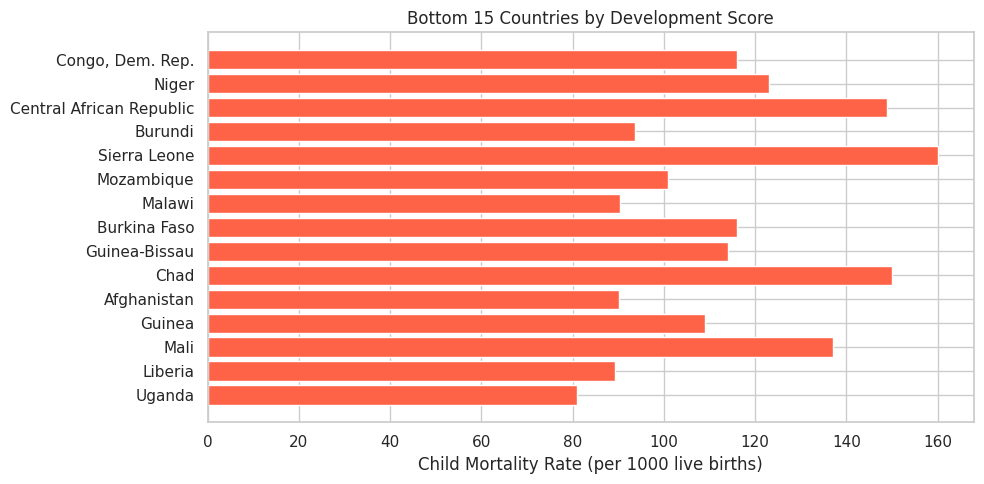

,country,child_mort,gdpp,life_expec,income
0,"Congo, Dem. Rep.",116.0,334,57.5,609
1,Niger,123.0,348,58.8,814
2,Central African Republic,149.0,446,47.5,888
3,Burundi,93.6,231,57.7,764
4,Sierra Leone,160.0,399,55.0,1220
5,Mozambique,101.0,419,54.5,918
6,Malawi,90.5,459,53.1,1030
7,Burkina Faso,116.0,575,57.9,1430
8,Guinea-Bissau,114.0,547,55.6,1390
9,Chad,150.0,897,56.5,1930


In [ ]:
aid = df.nsmallest(15, 'dev_score')[
    ['country', 'child_mort', 'gdpp', 'life_expec', 'income']
].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(aid['country'], aid['child_mort'], color='tomato', edgecolor='white')
ax.set_xlabel('Child Mortality Rate (per 1000 live births)')
ax.set_title('Bottom 15 Countries by Development Score')
ax.invert_yaxis()
plt.tight_layout()
plt.show()
aid

## 12. Summary

**Label Engineering:** Composite percentile-rank score across 5 indicators produces a balanced 3-class target, avoiding leakage from single-column median splits.

**Classification:** Tree-based models outperform Logistic Regression, confirming non-linear relationships in the data. XGBoost's L1/L2 regularisation makes it the most robust single model on this small dataset.

**Ensemble:** Soft Voting reduces prediction variance by aggregating probability outputs. Stacking improves further by learning an optimal combination via a meta-learner rather than a fixed voting rule.

**Clustering:** K-Means with silhouette-selected K recovers groupings aligned with the engineered tiers. DBSCAN identifies outlier countries — structurally unusual economies that K-Means would incorrectly force into a cluster.

**Segmentation:** Countries in Sub-Saharan Africa dominate the bottom tier — highest child mortality, lowest gdpp and income — providing clear, actionable segmentation insights.
